# Practice 1: convolution and edges


## Get an image to play with
I use `skimage`'s built-in photographer if it's installed, and fall back to a hand-drawn shape if not.
Either works for everything below.


In [1]:
%pip install numpy matplotlib scikit-image

Note: you may need to restart the kernel to use updated packages.


image shape: (512, 512)   min/max: 0.0 255.0


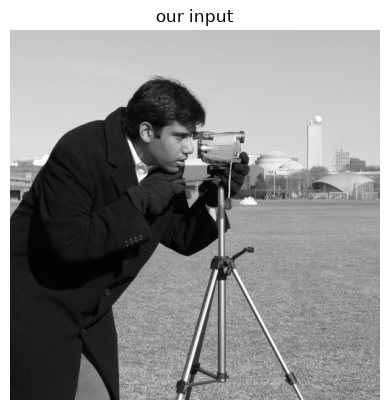

In [2]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from skimage import data
    img = data.camera().astype(float)
except Exception:
    img = np.full((128, 128), 30.0)
    img[30:90, 40:60] = 200      
    img[60:80, 70:110] = 120     

print('image shape:', img.shape, '  min/max:', img.min(), img.max())
plt.imshow(img, cmap='gray') 
plt.title('our input')
plt.axis('off')
plt.show()

## Your job: write the convolution
Slide a kernel over `img`. At each pixel, line the kernel up on the neighbourhood,
multiply element-wise, and sum. Pad with `mode='reflect'` so the borders don't go dark.

I've left you the scaffolding and the padding.
It will be slow (a Python double loop over every pixel)


In [3]:
img

array([[200., 200., 200., ..., 189., 190., 190.],
       [200., 199., 199., ..., 190., 190., 190.],
       [199., 199., 199., ..., 190., 190., 190.],
       ...,
       [ 25.,  25.,  27., ..., 139., 122., 147.],
       [ 25.,  25.,  26., ..., 158., 141., 168.],
       [ 25.,  25.,  27., ..., 151., 152., 149.]], shape=(512, 512))

In [3]:
def convolve2d(img, kernel):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode='reflect')
    out = np.zeros_like(img, dtype=float)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            patch = padded[y:y + kh, x:x + kw]
            out[y, x] = np.sum(patch * kernel)
    return out

### Check yourself before moving on
If your `convolve2d` is right, convolving with a kernel that is 1 in the centre and 0 elsewhere
(the identity) must return the image unchanged. The assert below will pass silently if you got it.


In [4]:
identity = np.zeros((3, 3)); identity[1, 1] = 1
assert np.allclose(convolve2d(img, identity), img), 'identity kernel should return the image unchanged'
print('nice, your convolution works')


nice, your convolution works


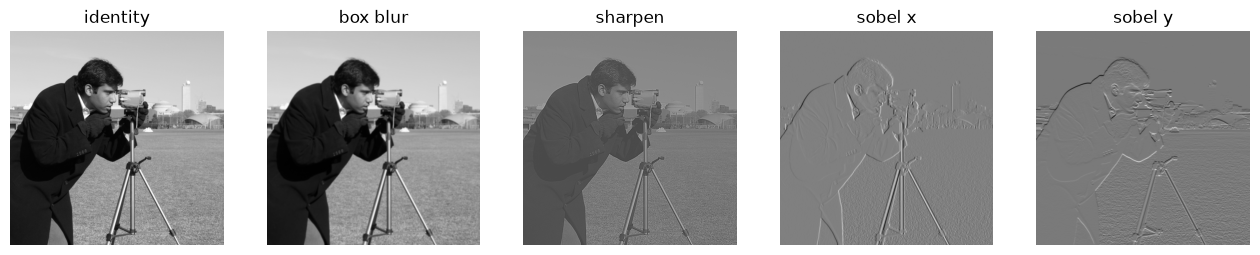

In [5]:
kernels = {
    'identity': np.array([[0,0,0],[0,1,0],[0,0,0]]),
    'box blur': np.ones((3,3)) / 9,
    'sharpen': np.array([[0,-1,0],[-1,5,-1],[0,-1,0]]),
    'sobel x': np.array([[-1,0,1],[-2,0,2],[-1,0,1]]),
    'sobel y': np.array([[-1,-2,-1],[0,0,0],[1,2,1]]),
}
fig, ax = plt.subplots(1, len(kernels), figsize=(16, 4))
for a, (name, k) in zip(ax, kernels.items()):
    a.imshow(convolve2d(img, k), cmap='gray'); a.set_title(name); a.axis('off')
plt.show()


## Build an edge detector (Canny)
Recipe from the lecture: blur first (so noise doesn't become fake edges), take the two Sobel
gradients, combine them into a magnitude, then threshold. You write the magnitude and the threshold.


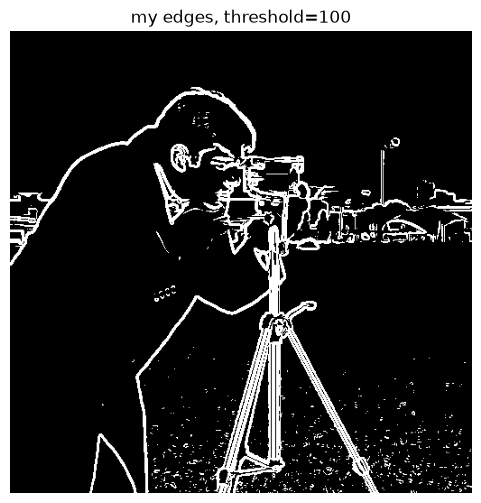

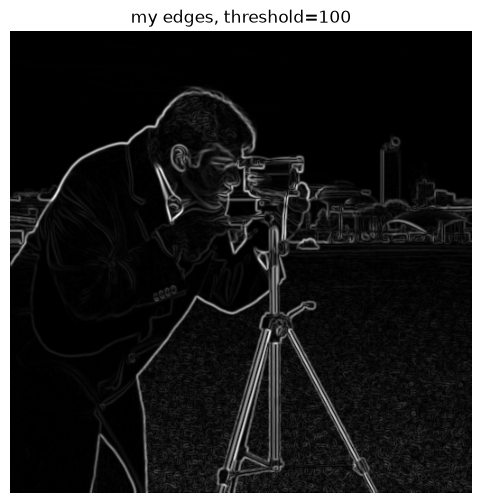

In [7]:
blur = convolve2d(img, np.array([[1,2,1],[2,4,2],[1,2,1]]) / 16) # blur the image 
gx = convolve2d(blur, kernels['sobel x'])
gy = convolve2d(blur, kernels['sobel y'])


# magnitude of the gradient at every pixel, from gx and gyz
mag = np.sqrt(gx**2 + gy**2)

# pick a threshold and make a black/white edge map
threshold = 100  # try a few values; what does too-low vs too-high look like?
edges = (mag > threshold).astype(float)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap='gray')
plt.title(f'my edges, threshold={threshold}')
plt.axis('off')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(mag, cmap='gray')
plt.title(f'my edges, threshold={threshold}')
plt.axis('off')
plt.show()

### Stretch (optional, harder)
Real Canny thins those fat edges down to one-pixel lines with *non-maximum suppression*: at each edge
pixel, keep it only if it is the local maximum along the gradient direction. Implement it and compare
your output to `cv2.Canny(img.astype('uint8'), 50, 150)`. They won't match exactly. Where do they differ?


## * Advanced extension: true Canny and separable blur
1. Finish real Canny: add non-maximum suppression along the gradient direction, then hysteresis with two thresholds
   (keep a weak edge only if it connects to a strong one). Compare against cv2.Canny. Cite Canny (1986).
2. A Gaussian blur is separable: a 2-D Gaussian equals two 1-D passes (rows, then columns), which is far faster.
   Implement the separable version and verify it matches your 2-D blur. This is why production code never convolves
   with a full 2-D Gaussian.


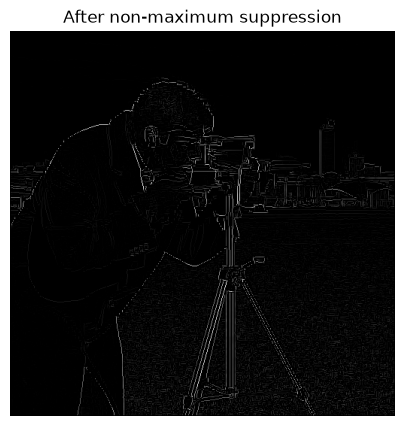

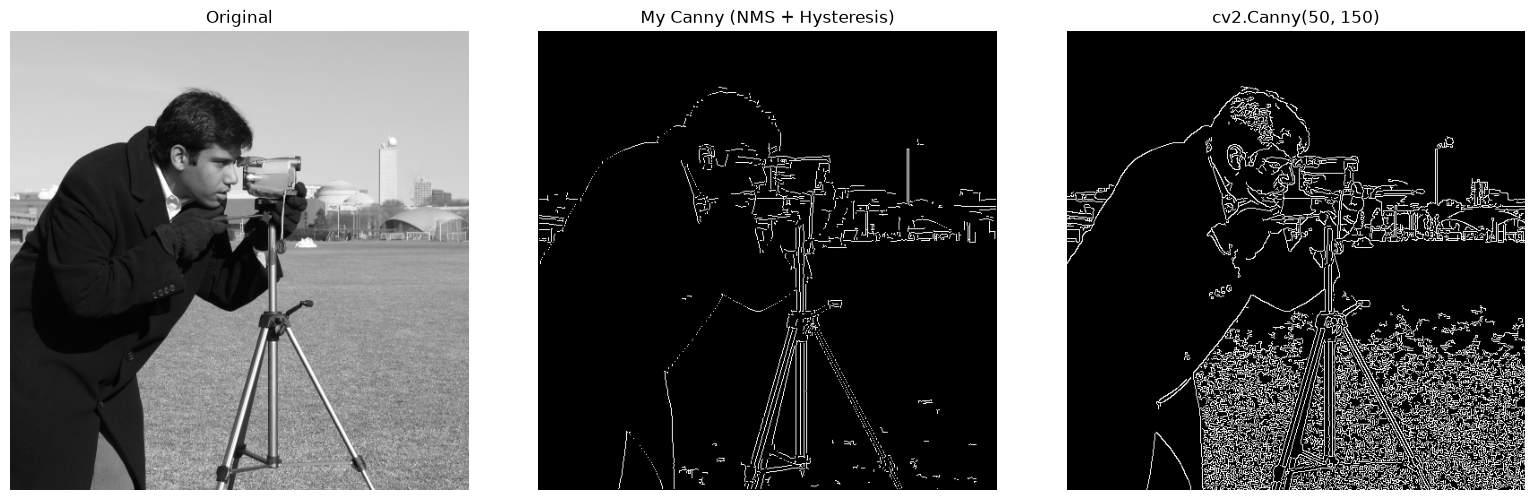

Pixels differing : 26985 / 262144  (10.29%)
IoU = 0.162  (overlap 5204, union 32189)


In [19]:
#1. True Canny with NMS + Hysteresis


# --- Build the quantized angle map ---
angle = np.arctan2(gy, gx) * 180.0 / np.pi
angle[angle < 0] += 180

angle_q = np.zeros_like(angle, dtype=np.int32)
conds = [
    (angle < 22.5) | (angle >= 337.5),
    (angle >= 22.5) & (angle < 67.5),
    (angle >= 67.5) & (angle < 112.5),
    (angle >= 112.5) & (angle < 157.5),
    (angle >= 157.5) & (angle < 202.5),
    (angle >= 202.5) & (angle < 247.5),
    (angle >= 247.5) & (angle < 292.5),
    (angle >= 292.5) & (angle < 337.5),
]
angle_q = np.select(conds, [0, 1, 2, 3, 0, 1, 2, 3], default=0)

#Non-Maximum Suppression

def non_max_suppression(mag, angle_q):
    """Keep a pixel only if it is a local maximum along the gradient direction.

    angle_q bins: 0=horizontal, 1=45°, 2=vertical, 135°
    """
    nms = np.zeros_like(mag)
    h, w = mag.shape

    for y in range(1, h - 1):
        for x in range(1, w - 1):
            q = angle_q[y, x]
            if   q == 0:  w1, w2 = (y, x-1), (y, x+1)
            elif q == 1:  w1, w2 = (y+1, x-1), (y-1, x+1)
            elif q == 2:  w1, w2 = (y-1, x), (y+1, x)
            else:         w1, w2 = (y-1, x-1), (y+1, x+1)

            if mag[y, x] >= mag[w1] and mag[y, x] >= mag[w2]:
                nms[y, x] = mag[y, x]

    return nms

nms = non_max_suppression(mag, angle_q)
plt.figure(figsize=(6, 5))
plt.imshow(nms, cmap='gray')
plt.title('After non-maximum suppression')
plt.axis('off')
plt.show()

#Hysteresis Thresholding

from collections import deque

def hysteresis(nms, low=50, high=150):
    """Strong edges (≥high) seed a flood-fill through weak edges (≥low).

    Weak edges not connected (8-neighbour) to any strong edge are discarded.
    """
    STRONG, WEAK = 2, 1
    edges = np.zeros_like(nms, dtype=np.int32)

    # classify every pixel
    edges[nms >= high] = STRONG
    edges[(nms >= low) & (nms < high)] = WEAK

    # propagate: each strong pixel floods through 8-neighbour weak pixels
    for y in range(nms.shape[0]):
        for x in range(nms.shape[1]):
            if edges[y, x] != STRONG:
                continue
            queue = deque([(y, x)])
            while queue:
                cy, cx = queue.popleft()
                for dy in (-1, 0, 1):
                    for dx in (-1, 0, 1):
                        if dy == 0 and dx == 0:
                            continue
                        ny, nx = cy + dy, cx + dx
                        if 0 <= ny < edges.shape[0] and 0 <= nx < edges.shape[1]:
                            if edges[ny, nx] == WEAK:
                                edges[ny, nx] = STRONG
                                queue.append((ny, nx))

    return (edges == STRONG).astype(float)

my_edges = hysteresis(nms, low=50, high=150)

#Compare Against cv2.Canny

import cv2

cv_edges = cv2.Canny(img.astype(np.uint8), 50, 150).astype(float) / 255.0

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(img, cmap='gray');        ax[0].set_title('Original')
ax[1].imshow(my_edges, cmap='gray');   ax[1].set_title('My Canny (NMS + Hysteresis)')
ax[2].imshow(cv_edges, cmap='gray');   ax[2].set_title('cv2.Canny(50, 150)')
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

#Some weak segments kept by CV but dropped by ours

Max absolute difference : 1.14e-13
Mean absolute difference: 1.36e-14
All close (tol=1e-10)   : True


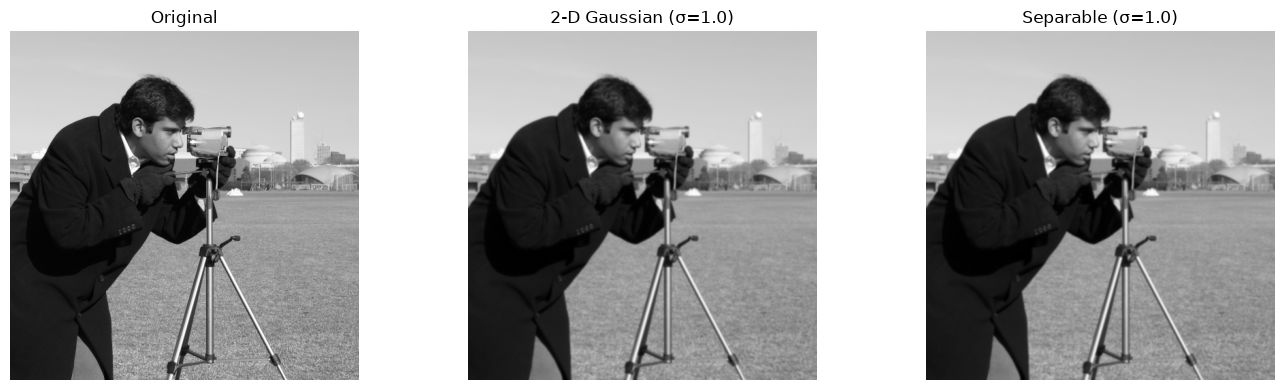

In [23]:
#2. Separable Gaussian Blur

#A 2-D Gaussian factorises:

#$$G(x,y;\sigma) = g(x;\sigma) \cdot g(y;\sigma)$$

#which means a 2-D convolution is equivalent to a row-wise 1-D pass followed by a column-wise 1-D pass — O(kn) instead of O(k²n).

def gaussian_kernel_1d(sigma=1.0):
    """Build a 1-D Gaussian kernel, truncated at ±3σ."""
    radius = int(3 * sigma + 0.5)
    x = np.arange(-radius, radius + 1)
    k = np.exp(-x**2 / (2 * sigma**2))
    return k / k.sum()

def gaussian_blur_2d(img, sigma=1.0):
    """2-D Gaussian blur via the full kernel (for comparison)."""
    k1d = gaussian_kernel_1d(sigma)
    k2d = np.outer(k1d, k1d)          # outer product = full 2-D Gaussian
    return convolve2d(img, k2d)

def gaussian_blur_separable(img, sigma=1.0):
    """Separable 1-D Gaussian blur: rows then columns.

    Equivalent to the 2-D blur but only 2 × O(k·N²) instead of O(k²·N²).
    """
    k1d = gaussian_kernel_1d(sigma)
    # pass 1 — convolve each row with the 1-D kernel
    kh = len(k1d)
    ph = kh // 2
    row_padded = np.pad(img, ((0, 0), (ph, ph)), mode='reflect')
    after_rows = np.zeros_like(img, dtype=float)
    for y in range(img.shape[0]):
        after_rows[y, :] = np.convolve(row_padded[y, :], k1d, mode='valid')

    # pass 2 — convolve each column with the 1-D kernel
    col_padded = np.pad(after_rows, ((ph, ph), (0, 0)), mode='reflect')
    out = np.zeros_like(img, dtype=float)
    for x in range(img.shape[1]):
        out[:, x] = np.convolve(col_padded[:, x], k1d, mode='valid')

    return out

#Verify They Match

sigma = 1.0
blur_2d  = gaussian_blur_2d(img, sigma)
blur_sep = gaussian_blur_separable(img, sigma)

diff = np.abs(blur_2d - blur_sep)
print(f"Max absolute difference : {diff.max():.2e}")
print(f"Mean absolute difference: {diff.mean():.2e}")
print(f"All close (tol=1e-10)   : {np.allclose(blur_2d, blur_sep, atol=1e-10)}")

# visual sanity check
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(img, cmap='gray');          ax[0].set_title('Original')
ax[1].imshow(blur_2d, cmap='gray');      ax[1].set_title(f'2-D Gaussian (σ={sigma})')
ax[2].imshow(blur_sep, cmap='gray');     ax[2].set_title(f'Separable (σ={sigma})')
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()
